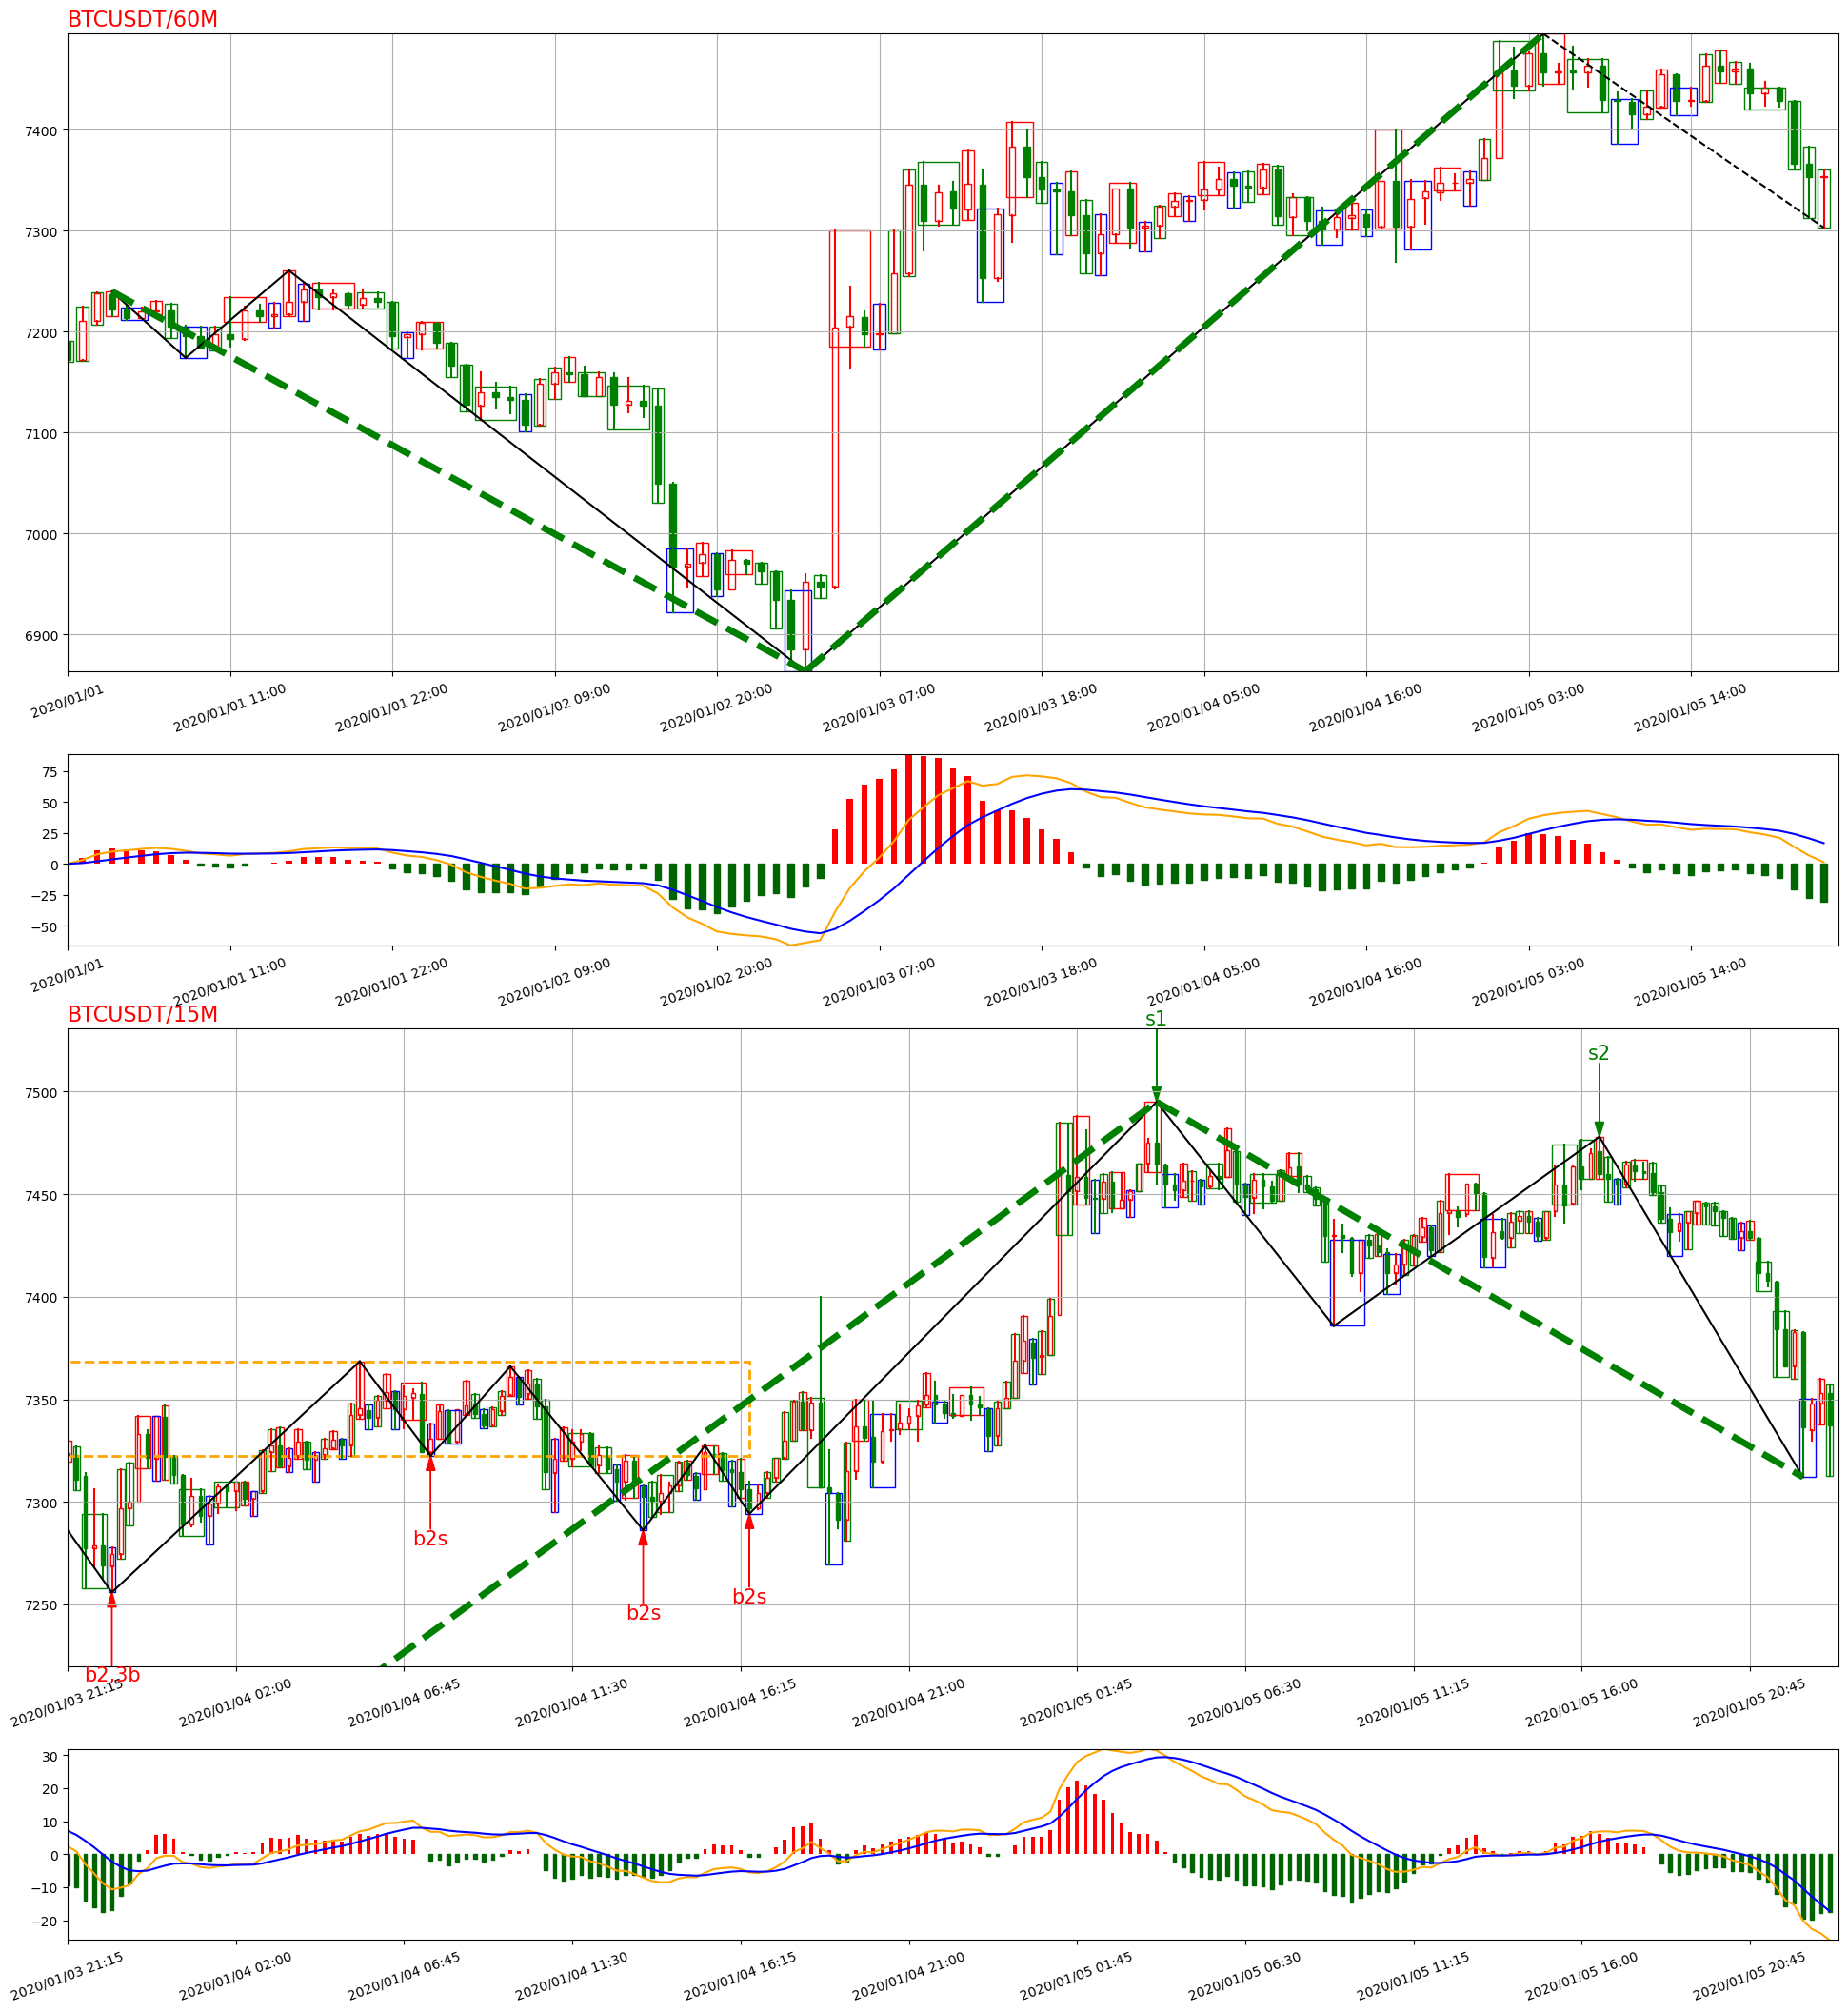

[WARNING-BTCUSDT]父级别时间是2020/01/06，次级别时间却是2020/01/05 23:15


CChanException: 父&子级别K线时间不一致条数超过5！！

In [3]:
# %load strategy_demo3.py

# ===== 必须放在最前面 =====
import sys
import os

project_root = os.path.abspath("..")  # Debug 的上一级

if project_root not in sys.path:
    sys.path.insert(0, project_root)

print("Project root:", project_root)
"""
示例：展示如何用更细级别的 K 线（15 分钟）合成更高级别的 K 线（60 分钟），
并演示将合成后的 K 线与原始小级别 K 线一并喂入 `CChan` 来刷新计算结果的思路。

注意：此脚本仅为演示，不一定能直接运行（示例聚焦用法而非完整可执行流程）。
"""

import copy
from typing import List

from Chan import CChan
from ChanConfig import CChanConfig
from Common.CEnum import AUTYPE, DATA_FIELD, DATA_SRC, KL_TYPE
from DataAPI.csvAPI import CSV_API
from Plot.AnimatePlotDriver import CAnimateDriver
from Plot.PlotDriver import CPlotDriver
from KLine.KLine_Unit import CKLine_Unit

def combine_60m_klu_form_15m(klu_15m_lst: List[CKLine_Unit]) -> CKLine_Unit:
    # 将 4 根 15 分钟 K 线合成为 1 根 60 分钟 K 线（取首开、末收、最高、最低、末时间）
    return CKLine_Unit(
        {
            DATA_FIELD.FIELD_TIME: klu_15m_lst[-1].time,
            DATA_FIELD.FIELD_OPEN: klu_15m_lst[0].open,
            DATA_FIELD.FIELD_CLOSE: klu_15m_lst[-1].close,
            DATA_FIELD.FIELD_HIGH: max(klu.high for klu in klu_15m_lst),
            DATA_FIELD.FIELD_LOW: min(klu.low for klu in klu_15m_lst),
        }
    )

if __name__ == "__main__":
    # 演示主流程：按 15 分钟 K 线步进、合成 60 分钟 K 线、深拷贝快照并触发计算
    # 该流程展示如何在不破坏原始快照的前提下，对每个小级别更新做独立计算与策略判断
    code = "BTCUSDT"  # 标的代码
    begin_time = "2025-02-04"  # 起始时间（用于回测）
    end_time = "2025-02-07"  # 结束时间，None 表示直到最新
    data_src_type = DATA_SRC.CSV  # 数据来源类型
    lv_list = [KL_TYPE.K_60M, KL_TYPE.K_15M]

    config = CChanConfig({
        "trigger_step": True,
    })

    # 绘图开关：按需开启或关闭各类子图
    plot_config = {
        "plot_kline": True,
        "plot_kline_combine": True,
        "plot_bi": True,
        "plot_seg": True,
        "plot_eigen": False,
        "plot_zs": True,
        "plot_macd": True,
        "plot_mean": False,
        "plot_channel": False,
        "plot_bsp": True,
        "plot_extrainfo": False,
        "plot_demark": False,
        "plot_marker": False,
        "plot_rsi": False,
        "plot_kdj": False,
    }

    # 绘图参数：局部绘制参数和图像范围
    plot_para = {
        "seg": {},
        "bi": {},
        "figure": {"x_range": 200},
        "marker": {},
    }

    # 快照
    chan_snapshot = CChan(
        code=code,
        data_src=data_src_type,
        lv_list=lv_list,
        config=config,
    )

    # 初始化并创建数据源
    CSV_API.do_init()
    data_src = CSV_API(code, k_type=KL_TYPE.K_15M, begin_date=begin_time, end_date=end_time, autype=AUTYPE.QFQ)  # 获取最小级别

    klu_15m_lst_tmp: List[CKLine_Unit] = []  # 存储用于合成当前60M K线的15M k线

    for klu_15m in data_src.get_kl_data():  # 获取单根15分钟K线
        klu_15m_lst_tmp.append(klu_15m)
        klu_60m = combine_60m_klu_form_15m(klu_15m_lst_tmp)  # 合成60分钟K线

        """
        拷贝一份chan_snapshot
        如果是用序列化方式，这里可以采用pickle.load()
        """
        chan: CChan = copy.deepcopy(chan_snapshot)
        chan.trigger_load({KL_TYPE.K_60M: [klu_60m], KL_TYPE.K_15M: klu_15m_lst_tmp})

        """
        策略开始：
        这里基于chan实现你的策略
        """
        for kl_type, ele_manager in chan.kl_datas.items():
            # 打印当前每一级别分别有多少K线
            print(klu_15m.time, kl_type, sum(len(klc) for klc in ele_manager))
        # 策略结束：

        if len(klu_15m_lst_tmp) == 4:  # 已经完成4根15分钟K线了，说明这个最新的60分钟K线和里面的4根15分钟K线在将来不会再变化
            """
            把当前完整chan重新保存成chan_snapshot
            如果是序列化方式，这里可以采用pickle.dump()
            """
            chan_snapshot = chan
            klu_15m_lst_tmp = []  # 清空1分钟K线，用于下一个五分钟周期的合成

    # 关闭数据源
    CSV_API.do_close()
    
    # 根据是否为动图模式选择静态或动画绘制
    if not config.trigger_step:
        plot_driver = CPlotDriver(chan_snapshot, plot_config=plot_config, plot_para=plot_para)
        plot_driver.figure.show()          # 在交互环境显示
        plot_driver.save2img("./result/test.png")
    else:
        CAnimateDriver(chan_snapshot, plot_config=plot_config, plot_para=plot_para)

